# Assignment 3

You only need to write one line of code for each question. When answering questions that ask you to identify or interpret something, the length of your response doesn’t matter. For example, if the answer is just ‘yes,’ ‘no,’ or a number, you can just give that answer without adding anything else.

We will go through comparable code and concepts in the live learning session. If you run into trouble, start by using the help `help()` function in Python, to get information about the datasets and function in question. The internet is also a great resource when coding (though note that **no outside searches are required by the assignment!**). If you do incorporate code from the internet, please cite the source within your code (providing a URL is sufficient).

Please bring questions that you cannot work out on your own to office hours, work periods or share with your peers on Slack. We will work with you through the issue.

### Clustering and Resampling

Let's set up our workspace and use the **Wine dataset** from `scikit-learn`. This dataset is a classic dataset used for clustering tasks. It consists of many samples of wine. Here are the key features and characteristics of the dataset:

##### Features (13 chemical properties):
1. Alcohol: The percentage of alcohol in the wine.
2. Malic acid: A type of acid found in grapes, contributing to wine’s tartness.
3. Ash: The total amount of non-volatile substances left after burning the wine
4. Alcalinity of ash: Measures the alkalinity of the ash component of wine.
5. Magnesium: The amount of magnesium in the wine (measured in mg/L).
6. Total phenols: Represents the total amount of phenolic compounds in wine.
7. Flavanoids: A type of phenolic compound responsible for bitterness and astringency.
8. Nonflavanoid phenols: Phenolic compounds that are not flavonoids.
9. Proanthocyanins: A type of tannin that affects astringency and bitterness.
10. Color intensity: Measures the depth or intensity of the wine’s color. 
11. Hue: The shade of color in the wine (ratio of red to yellow tones).
12. OD280/OD315 of diluted wines: Measures the wine’s absorbance at 280 nm and 315 nm, indicating phenol concentration.
13. Proline: An amino acid found in wine, often associated with aging potential and quality.

In [8]:
# Import standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans


#### **Question 1:** 
#### Data inspection

#### Load the Wine dataset:

Use scikit-learn to load the Wine dataset and convert it into a Pandas DataFrame.
Display the first few rows of the dataset. How many observations (rows) and features (columns) does the dataset contain?

In [16]:
from sklearn.datasets import load_wine
# Load the Wine dataset
wine_data = load_wine()

# Convert to DataFrame
wine_df = pd.DataFrame(wine_data.data, columns=wine_data.feature_names)

# Display the DataFrame
print(wine_df)

# Your code here...
print(f"The number of records in the dataset are: {wine_df.shape[0]}")
print(f"The number of features in the dataset are: {wine_df.shape[1]}")

     alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0      14.23        1.71  2.43               15.6      127.0           2.80   
1      13.20        1.78  2.14               11.2      100.0           2.65   
2      13.16        2.36  2.67               18.6      101.0           2.80   
3      14.37        1.95  2.50               16.8      113.0           3.85   
4      13.24        2.59  2.87               21.0      118.0           2.80   
..       ...         ...   ...                ...        ...            ...   
173    13.71        5.65  2.45               20.5       95.0           1.68   
174    13.40        3.91  2.48               23.0      102.0           1.80   
175    13.27        4.28  2.26               20.0      120.0           1.59   
176    13.17        2.59  2.37               20.0      120.0           1.65   
177    14.13        4.10  2.74               24.5       96.0           2.05   

     flavanoids  nonflavanoid_phenols  proanthocyan

#### **Question 2:** 
#### Data-visualization

Let's create plots to visualize the relationships between the features (e.g., alcohol, malic acid, ash...).


In [17]:
wine_df.columns

Index(['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
       'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
       'proanthocyanins', 'color_intensity', 'hue',
       'od280/od315_of_diluted_wines', 'proline'],
      dtype='object')

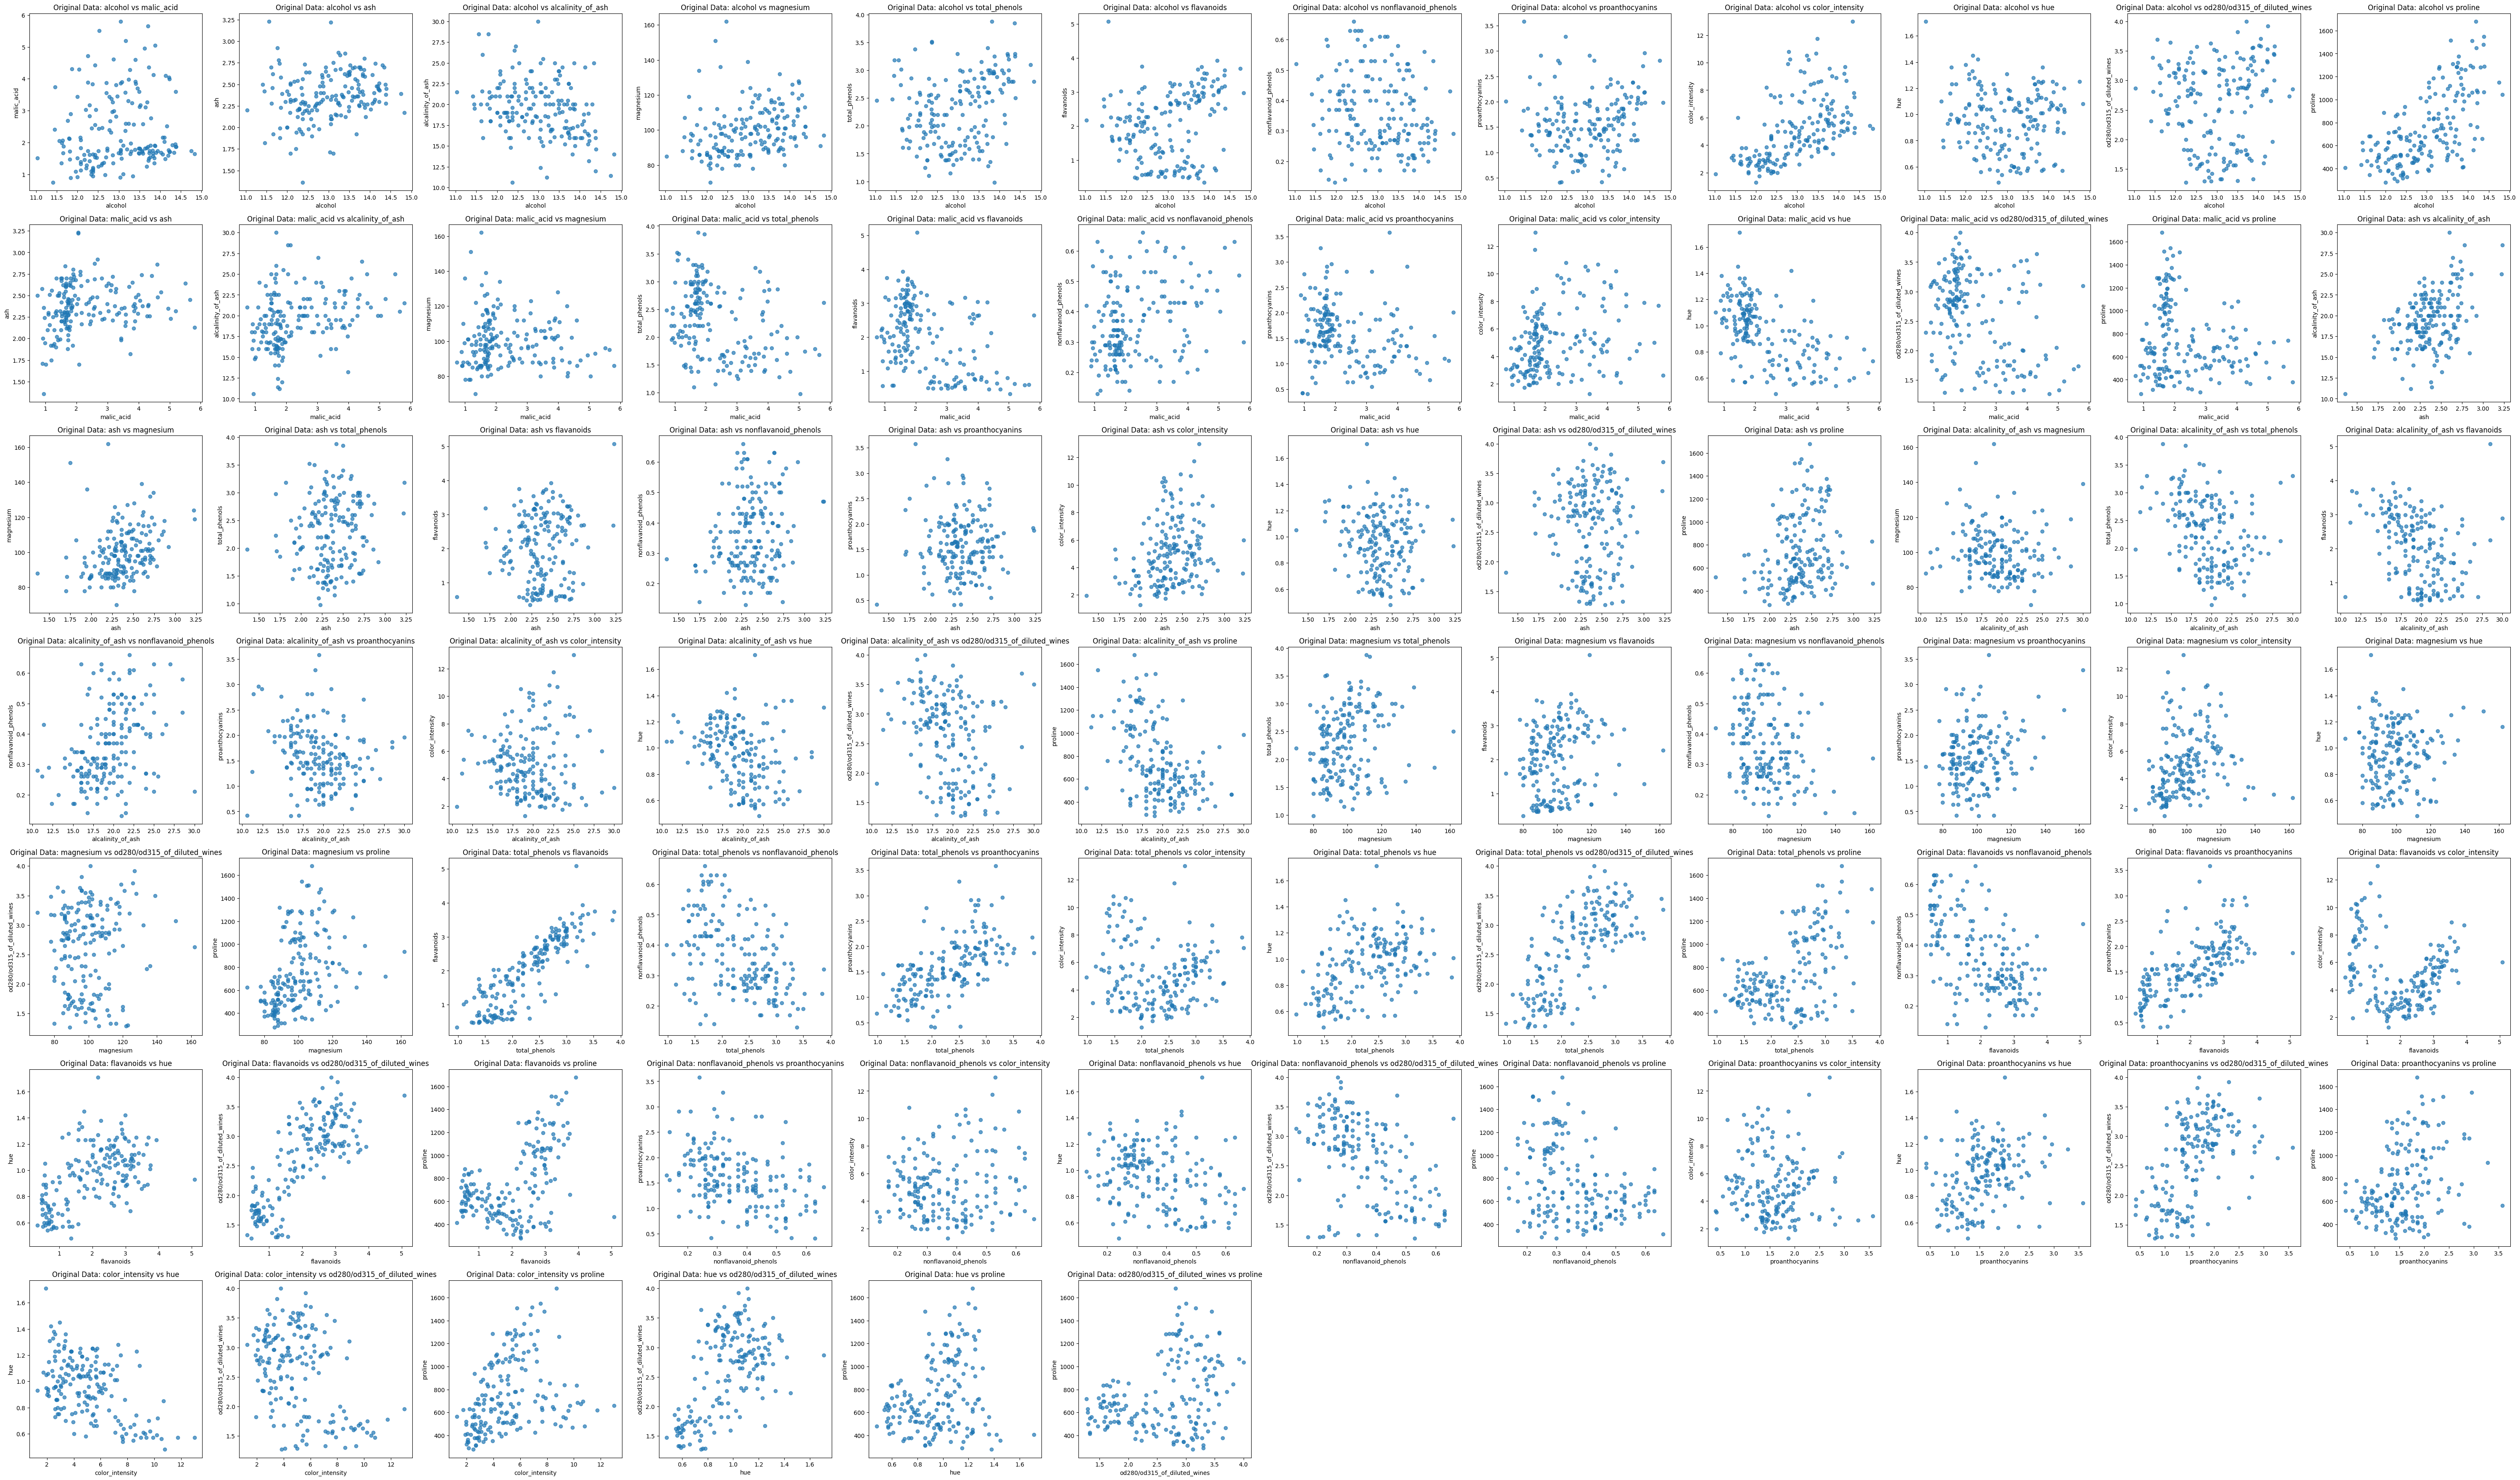

In [6]:
def plot_feature_pairs(data, feature_names, color_labels=None, title_prefix=''):
    """
    Helper function to create scatter plots for all possible pairs of features.
    
    Parameters:
    - data: DataFrame containing the features to be plotted.
    - feature_names: List of feature names to be used in plotting.
    - color_labels: Optional. Cluster or class labels to color the scatter plots.
    - title_prefix: Optional. Prefix for plot titles to distinguish between different sets of plots.
    """
    # Create a figure for the scatter plots
    plt.figure(figsize=(60, 60))
    
    # Counter for subplot index
    plot_number = 1
    
    # Loop through each pair of features
    for i in range(len(feature_names)):
        for j in range(i + 1, len(feature_names)):
            plt.subplot(len(feature_names)-1, len(feature_names)-1, plot_number)
            
            # Scatter plot colored by labels if provided
            if color_labels is not None:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], 
                            c=color_labels, cmap='viridis', alpha=0.7)
            else:
                plt.scatter(data[feature_names[i]], data[feature_names[j]], alpha=0.7)
            
            plt.xlabel(feature_names[i])
            plt.ylabel(feature_names[j])
            plt.title(f'{title_prefix}{feature_names[i]} vs {feature_names[j]}')
            
            # Increment the plot number
            plot_number += 1

    # Adjust layout to prevent overlap
    plt.tight_layout()

    # Show the plot
    plt.show()

# Get feature names
feature_names = wine_df.columns

# Use the helper function to plot scatter plots without coloring by cluster labels
plot_feature_pairs(wine_df, feature_names, title_prefix='Original Data: ')

**Question:**
- Do you notice any patterns or relationships between the different features? How might these patterns help in distinguishing between different species?

> Your answer...  
Yes, clear patterns and relationships among the features can be noticed.
Below is the Feature pairs and the Relationship type.    
Flavanoids–Total Phenols, Alcohol–Proline             - Positive  
Color Intensity–Hue, Flavanoids–Nonflavanoid Phenols  - Negative    
Ash–Alcohol, Magnesium–Hue      					  - Weak/No relationship  
Different wine species have distinct chemical compositions. These patterns help distinguish species by creating distinct clusters, defining chemical fingerprints and providing clear boundaries and seperations.

#### **Question 3:** 
#### Data cleaning

In [21]:
# Initialize the StandardScaler
scaler = StandardScaler()

# Scale all the features in the dataset
scaled_features = scaler.fit_transform(wine_df)

# Create a new DataFrame with scaled features
scaled_wine_df = pd.DataFrame(scaled_features, columns=wine_data.feature_names)

# Display the first few rows of the scaled DataFrame
print(scaled_wine_df.head())

    alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0  1.518613   -0.562250  0.232053          -1.169593   1.913905   
1  0.246290   -0.499413 -0.827996          -2.490847   0.018145   
2  0.196879    0.021231  1.109334          -0.268738   0.088358   
3  1.691550   -0.346811  0.487926          -0.809251   0.930918   
4  0.295700    0.227694  1.840403           0.451946   1.281985   

   total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0       0.808997    1.034819             -0.659563         1.224884   
1       0.568648    0.733629             -0.820719        -0.544721   
2       0.808997    1.215533             -0.498407         2.135968   
3       2.491446    1.466525             -0.981875         1.032155   
4       0.808997    0.663351              0.226796         0.401404   

   color_intensity       hue  od280/od315_of_diluted_wines   proline  
0         0.251717  0.362177                      1.847920  1.013009  
1        -0.293321  0.406051

Why is it important to standardize the features of a dataset before applying clustering algorithms like K-Means? Discuss the implications of using unstandardized data in your analysis.

> Your answer here ...  
Standardizing the features before applying clustering algorithms like K-Means is important because K-Means is distance-based, and the scale of the features directly affects how distances are calculated and how clusters are formed. K-Means typically uses Euclidean distance to measure similarity between data points. If the features in a dataset are on different scales, features with larger numeric ranges will dominate the distance calculation even if they are of not more important.  
Standardization ensures that:  
Each feature contributes equally to the distance computation.  
The clustering reflects patterns in the data, not just differences in measurement units.  
If you apply K-Means on unstandardized data, below are the implications.  
Bias towards large-scale features: Variables with larger magnitudes will disproportionately influence cluster formation  
Misleading clusters: Clusters may reflect scale differences rather than true similarity between data points  
Reduced interpretability: The resulting clusters may not align with domain knowledge or real-world behavior  
Poor generalization: Clustering results may change drastically if units or scales are modified  

#### **Question 4:** 
#### K-means clustering 

Apply the K-Means clustering algorithm to the Wine dataset. Choose the value 3 for the number of clusters (`k=3`) and fit the model. Assign cluster labels to the original data and add them as a new column in the DataFrame.

In [23]:
from sklearn import set_config
set_config(transform_output="pandas")

In [ ]:
kmeans = KMeans(n_clusters= 3, random_state= 52, n_init=10) # Initialize our model for K=3

wine_clusters = kmeans.fit(scaled_wine_df)     # Fit the model to the scaled data

In [ ]:
wine_clusters.labels_    # Verify the clusters

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0], dtype=int32)

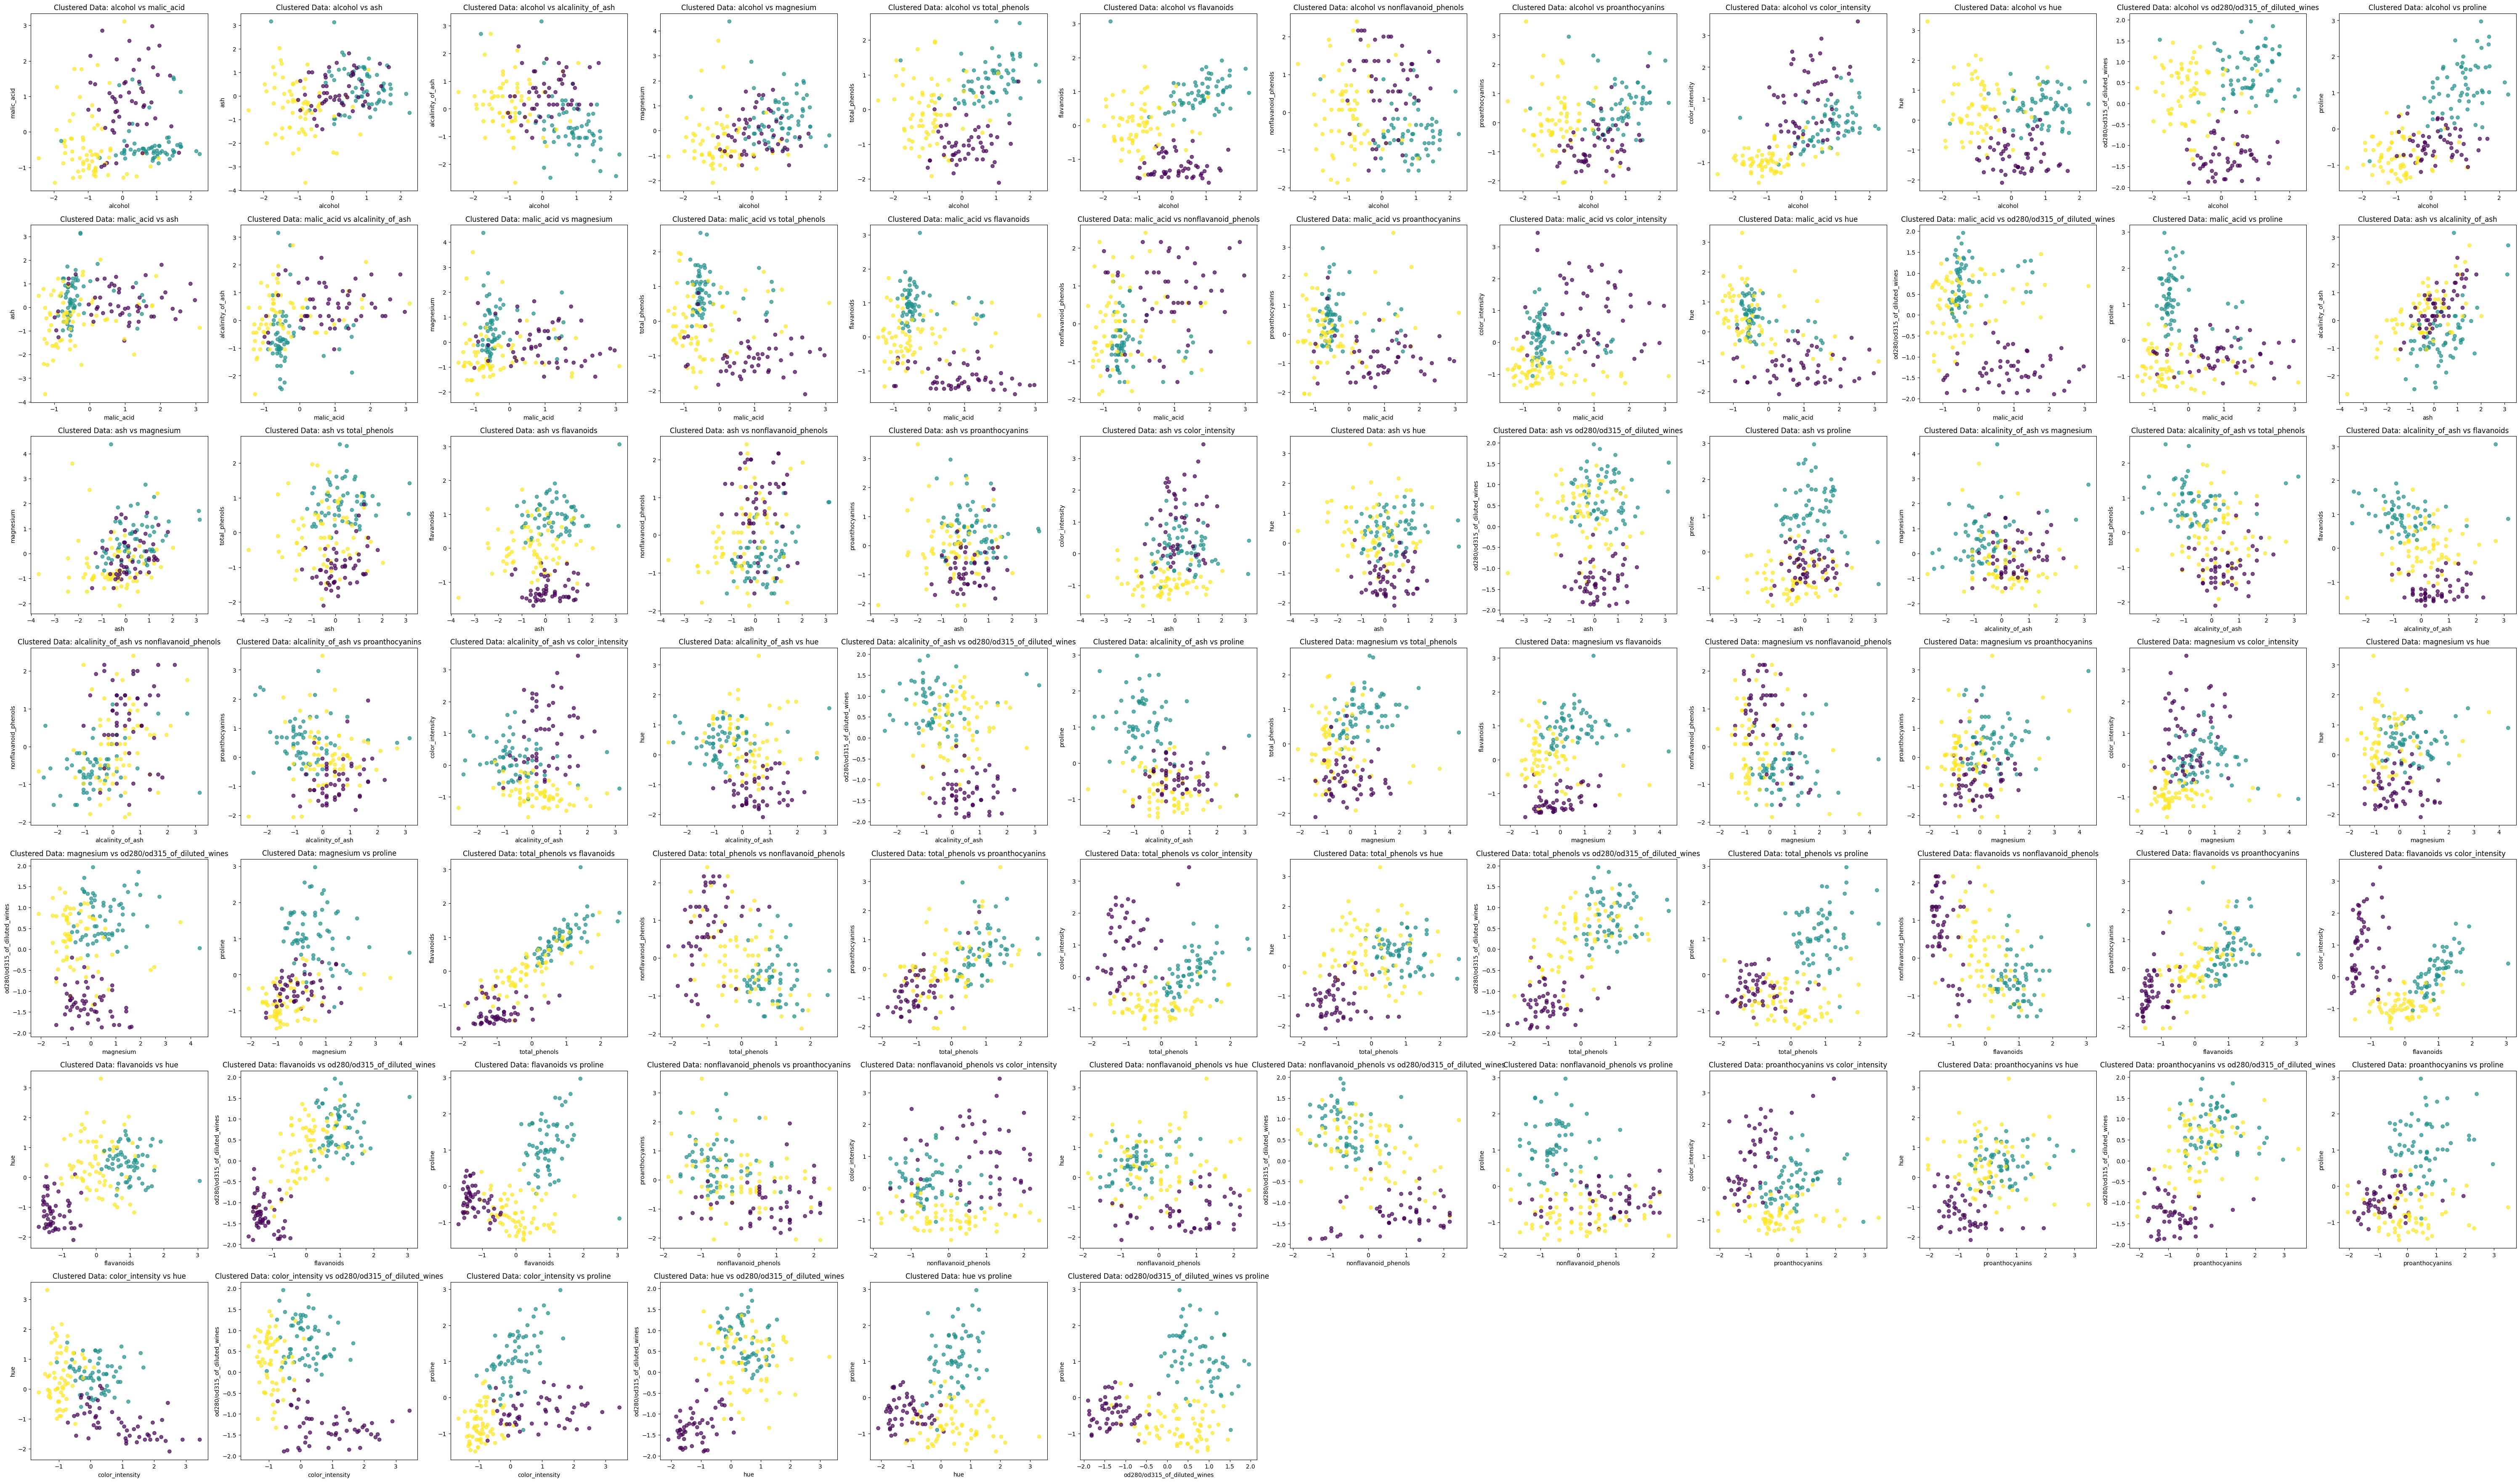

In [45]:
# Your answer...

clustered_wine_data = scaled_wine_df.copy()    # Copy the scaled data from df 

clustered_wine_data["Cluster"] = wine_clusters.labels_ # Add cluster labels back to the data set

feature_names = scaled_wine_df.columns

# Use the helper function to plot scatter plots, colored by cluster labels
plot_feature_pairs(clustered_wine_data, feature_names, color_labels=clustered_wine_data['Cluster'], title_prefix='Clustered Data: ')

In [46]:
kmeans.inertia_

1277.9284888446423

We chose `k=3` for the number of clusters arbitrarily. However, in a real-world scenario, it is important to determine the optimal number of clusters using appropriate methods.

**Question**: What is one method commonly used to determine the optimal number of clusters in K-means clustering, and why is this method helpful?

> Your answer here...  
The Elbow method is commonly used to determine the optimal number of clusters in K-means clustering. This method helps identify the optimal number of clusters by showing visually in the WSSD vs K plot, where by increasing K stops meaningful improvement allowing to chose simple and effective clustering solution. 

#### **Question 5:** 
#### Bootstrapping 

Implement bootstrapping on the mean of `color intensity`. Generate 10000 bootstrap samples, calculate the mean for each sample, and compute a 90% confidence interval.

In [92]:
wine_df   # Original wine dataset

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [93]:
wine_df["color_intensity"].mean()   ## Calculate the population mean

np.float64(5.058089882022472)

In [94]:
np.random.seed(123)

In [95]:
one_wine_sample = wine_df.sample(n = 20)   # Take one sample of 20
one_wine_sample["color_intensity"].mean()  # Calculate the sample mean

np.float64(5.311)

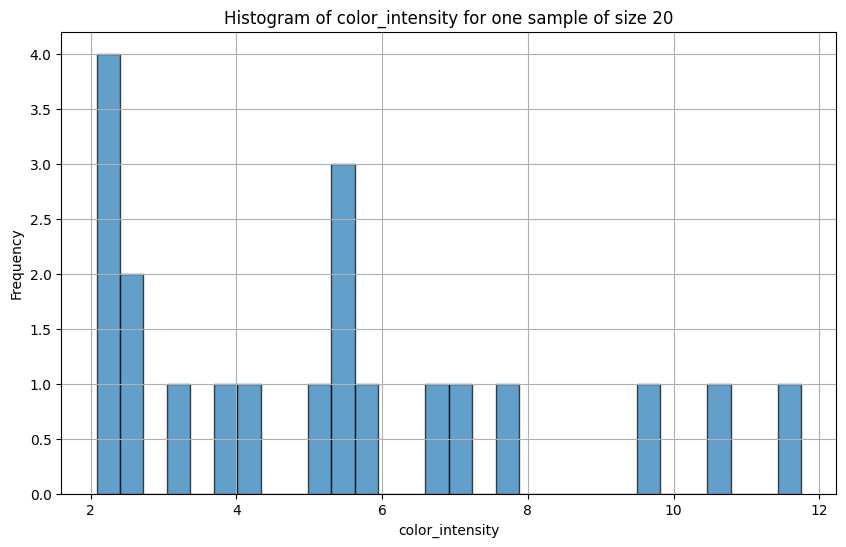

In [96]:
# Histogram of color intensity for one sample of size 20.
plt.figure(figsize=(10, 6))
plt.hist(one_wine_sample['color_intensity'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of color_intensity for one sample of size 20')
plt.xlabel('color_intensity')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [97]:
boot1 = one_wine_sample.sample(frac = 1, replace = True)  # bootstrap the sample with fraction and replacement

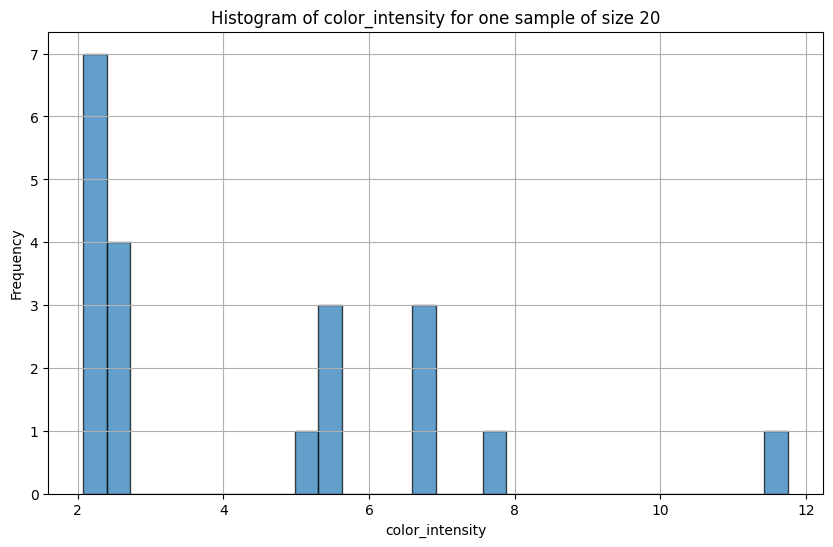

In [98]:
# Histogram of color intensity for one sample of size 20.
plt.figure(figsize=(10, 6))
plt.hist(boot1['color_intensity'], bins=30, edgecolor='black', alpha=0.7)

# Add titles and labels
plt.title('Histogram of color_intensity for one sample of size 20')
plt.xlabel('color_intensity')
plt.ylabel('Frequency')

# Show the plot
plt.grid(True)
plt.show()

In [99]:
wine_bootstrap_samples = [] #Initialize an empty list

for i in range(10_000):
    sample = one_wine_sample.sample(frac = 1, replace = True)
    sample = sample.assign(replicate = i)
    wine_bootstrap_samples.append(sample)

In [100]:
boot10000_wine = pd.concat(wine_bootstrap_samples)

In [ ]:
# Your answer here...

mean_color_intensity = boot10000_wine.groupby("replicate")["color_intensity"].mean().reset_index(name='mean_color_intensity')

np.random.seed(123)

lower_bound = mean_color_intensity["mean_color_intensity"].quantile([0.05])
upper_bound = mean_color_intensity["mean_color_intensity"].quantile([0.95])

# Display the result
print(f"Mean of Color Intensity: {mean_color_intensity}")
print(f"90% Confidence Interval of Mean Color Intensity: ({lower_bound}, {upper_bound})")

Mean of Color Intensity:       replicate  mean_color_intensity
0             0                5.6905
1             1                4.8000
2             2                5.1260
3             3                4.6395
4             4                4.3845
...         ...                   ...
9995       9995                5.1260
9996       9996                4.6170
9997       9997                5.3830
9998       9998                4.8450
9999       9999                5.6785

[10000 rows x 2 columns]
90% Confidence Interval of Mean Color Intensity: (0.05    4.312975
Name: mean_color_intensity, dtype: float64, 0.95    6.395075
Name: mean_color_intensity, dtype: float64)


**Question:**
- Why do we use bootstrapping in this context? What does it help us understand about the mean?

>  Your answer...  
We use bootstrapping in this context to understand how reliable the sample mean is.   
In the real world scenarios we usually have only one sample and will not know the true population distribution or the population mean.  
Bootstrapping helps us approximate the sampling distribution of the mean. From the bootstrap distribution we can estimate the confidence intervals without strong assumptions.

**Question:**
- What is the purpose of calculating the confidence interval from the bootstrap samples? How does it help us interpret the variability of the estimate?

> Your answer...  
The main purpose of a bootstrap confidence interval is to quantify the uncertainty around an estimated mean when the true population value is unknown. Instead of giving just a single number, the confidence interval provides a range of plausible values for the true parameter.  
The confidence interval helps us interpret the variability of the estimate as below.  
Narrow Confidence Interval → low variability  → estimate is precise and stable  
Wide Confidence Interval   → high variability → estimate is uncertain

**Question:**

- Reflect on the variability observed in the bootstrapped means and discuss whether the mean of the color intensity appears to be a stable and reliable estimate based on the confidence interval and the spread of the bootstrapped means.

> Your answer here...  
The bootstrap results show that the mean color intensity has a 90% confidence interval approximately from 4.31 to 6.39. This interval provides important insight into the variability and reliability of the estimate.  
First, the spread of the bootstrapped means is moderate rather than extremely wide. This suggests that while the mean color intensity does vary across resampled datasets, indicating that the estimate is not overly sensitive to random resampling.  
Second, the confidence interval is well-defined and bounded implies a reasonable level of precision. The interval width of about 2.16 units suggests moderate uncertainty but acceptable stability.  
Finally as the bootstrap confidence interval is directly generated from the actualy data without strong assumptions, stregthens the confidence in the result.

# Criteria


| **Criteria**                                           | **Complete**                                      | **Incomplete**                                    |
|--------------------------------------------------------|---------------------------------------------------|--------------------------------------------------|
| **Data Inspection**                                    | Data is thoroughly inspected for the number of variables, observations, and data types, and relevant insights are noted. | Data inspection is missing or lacks detail.         |
| **Data Visualization**                                 | Visualizations (e.g., scatter plots) are correctly interpreted to explore relationships between features and species. | Visualizations are not correctly interpreted. |
| **Clustering Implementation**                           | K-Means clustering is correctly implemented, and cluster labels are appropriately assigned to the dataset.            | K-Means clustering is missing or incorrectly implemented. |
| **Bootstrapping Process**                              | Bootstrapping is correctly performed, and results are used to assess variable mean stability. | Bootstrapping is missing or incorrectly performed. |

## Submission Information

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Note:

If you like, you may collaborate with others in the cohort. If you choose to do so, please indicate with whom you have worked with in your pull request by tagging their GitHub username. Separate submissions are required.

### Submission Parameters:
* Submission Due Date: `11:59 PM - 12/10/2025`
* The branch name for your repo should be: `assignment-3`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_3.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/LCR/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#dc2-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
